In [5]:

# --- Environment bootstrap (safe to re-run) ---
# Installs minimal pinned versions to avoid common Windows build issues (e.g., NumPy 2.x ABI).
import sys, subprocess, importlib, pkgutil

def ensure(pkg, version):
    try:
        mod = importlib.import_module(pkg)
        print(f"{pkg} already installed: {getattr(mod, '__version__', 'unknown')}")
    except Exception:
        print(f"Installing {pkg}=={version} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", f"{pkg}=={version}"])

# Pinned versions known to work well on Windows/Python 3.10
ensure("numpy", "1.26.4")
ensure("pandas", "2.1.4")
ensure("sklearn", "1.3.2")   # scikit-learn
ensure("matplotlib", "3.8.0")

print("✅ Dependencies are ready. If VS Code prompts, please **Restart Kernel** once, then run all cells.")


numpy already installed: 1.26.4
pandas already installed: 2.3.3
sklearn already installed: 1.7.2
matplotlib already installed: 3.10.7
✅ Dependencies are ready. If VS Code prompts, please **Restart Kernel** once, then run all cells.


In [11]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error as _mse

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

SEARCH_PATHS = ['.', '/mnt', './data']

def find_file(fname):
    for p in SEARCH_PATHS:
        full = os.path.join(p, fname)
        if os.path.exists(full):
            return full
    return None

def rmse(y_true, y_pred):
    try:
        # Newer sklearn (>=0.22)
        return _mse(y_true, y_pred, squared=False)
    except TypeError:
        # Older sklearn: no 'squared' kwarg
        return np.sqrt(_mse(y_true, y_pred))



# Time Series ML Pipeline (Stocks): CV, Model Comparison, and Submission


In [ ]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

SEARCH_PATHS = ['.', '/mnt/data', './data']

def find_file(fname):
    for p in SEARCH_PATHS:
        full = os.path.join(p, fname)
        if os.path.exists(full):
            return full
    return None

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


In [12]:

train_path = find_file('train.pkl')
test_path  = find_file('test.pkl')

if (train_path is not None) and (test_path is not None):
    train = pd.read_pickle(train_path)
    test  = pd.read_pickle(test_path)
    print(f"Loaded train from: {train_path}  shape={train.shape}")
    print(f"Loaded test  from: {test_path}   shape={test.shape}")
else:
    print("Kaggle files not found. Creating a tiny synthetic dataset so the pipeline runs.")
    n_train = 1500
    n_test  = 500
    dates   = pd.date_range('2020-01-01', periods=n_train + n_test, freq='D')
    codes   = np.random.choice(['AAA','BBB','CCC','DDD'], size=(n_train + n_test,))
    features = np.random.randn(n_train + n_test, 20)
    y = 0.7*features[:,0] - 0.4*features[:,3] + 0.3*features[:,7] + 0.0005*np.arange(n_train + n_test) + np.random.randn(n_train + n_test)*0.1
    df = pd.DataFrame(features, columns=[f"f_{i}" for i in range(20)])
    df['code'] = codes
    df['date'] = dates
    df['y'] = y
    train = df.iloc[:n_train].copy()
    test  = df.iloc[n_train:].drop(columns=['y']).copy()

feature_cols = [c for c in train.columns if c.startswith('f_')]
assert 'code' in train.columns and 'date' in train.columns and 'y' in train.columns
assert 'code' in test.columns and 'date' in test.columns


Loaded train from: .\train.pkl  shape=(2431658, 23)
Loaded test  from: .\test.pkl   shape=(869269, 23)


In [13]:

train = train.sort_values(['date','code']).reset_index(drop=True)
test  = test.sort_values(['date','code']).reset_index(drop=True)
X = train[feature_cols].copy()
y = train['y'].astype(float).values
X_test = test[feature_cols].copy()
print("Train features:", X.shape, " Test features:", X_test.shape)


Train features: (2431658, 20)  Test features: (869269, 20)


In [16]:
# ===== Fast Dev Mode (speeds up CV) =====
FAST_DEV = True   # set False for full run
MAX_CODES = 10
PER_CODE  = 150   # rows per code to keep (latest only)

if FAST_DEV:
    codes = pd.Series(train['code'].unique())
    codes_to_keep = (codes.sample(MAX_CODES, random_state=SEED).tolist()
                     if len(codes) > MAX_CODES else codes.tolist())
    train = (train[train['code'].isin(codes_to_keep)]
                .sort_values(['code','date'])
                .groupby('code', group_keys=False)
                .tail(PER_CODE)
                .sort_values(['date','code'])
                .reset_index(drop=True))
    X = train[feature_cols].copy()
    y = train['y'].astype(float).values
    print(f"FAST_DEV -> rows={len(train)}, codes={train['code'].nunique()}, per_code={PER_CODE}")

N_SPLITS = 3 if FAST_DEV else 5


FAST_DEV -> rows=1500, codes=10, per_code=150


In [17]:

n_splits = N_SPLITS
tscv = TimeSeriesSplit(n_splits=n_splits)

models = {
    "HGBR": HistGradientBoostingRegressor(
        random_state=SEED,
        max_depth=8 if FAST_DEV else None,
        learning_rate=0.05,
        max_iter=200 if FAST_DEV else 400,
    ),
    "RF": RandomForestRegressor(
        n_estimators=200 if FAST_DEV else 600,
        random_state=SEED,
        n_jobs=-1,
        max_depth=12 if FAST_DEV else None,
        max_features="sqrt",
    ),
    "ET": ExtraTreesRegressor(
        n_estimators=300 if FAST_DEV else 800,
        random_state=SEED,
        n_jobs=-1,
        max_depth=12 if FAST_DEV else None,
        max_features="sqrt",
    ),
}

import numpy as _np
cv_scores = {name: [] for name in models}
oof_preds = {name: _np.zeros(len(train)) for name in models}

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    for name, mdl in models.items():
        mdl.fit(X_tr, y_tr)
        p = mdl.predict(X_va)
        cv_scores[name].append(rmse(y_va, p))
        oof_preds[name][va_idx] = p
    print(f"Fold {fold+1}/{n_splits} done.")

import pandas as _pd
cv_summary = _pd.DataFrame({name: scores for name, scores in cv_scores.items()})
cv_summary.loc['CV_RMSE'] = cv_summary.mean(axis=0)
cv_summary


Fold 1/3 done.
Fold 2/3 done.
Fold 3/3 done.


,HGBR,RF,ET
0,0.060808,0.057436,0.058465
1,0.054691,0.052167,0.051417
2,0.049347,0.043090,0.041163
CV_RMSE,0.054949,0.050898,0.050349


Best model by CV RMSE: ET => 0.050349


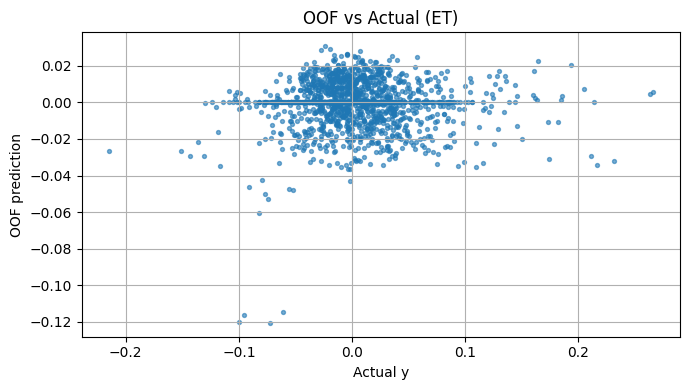

In [18]:

best_model_name = cv_summary.loc['CV_RMSE'].astype(float).idxmin()
best_cv = cv_summary.loc['CV_RMSE', best_model_name]
print("Best model by CV RMSE:", best_model_name, "=>", round(float(best_cv), 6))

oof = oof_preds[best_model_name]
plt.figure(figsize=(7,4))
plt.scatter(y, oof, s=8, alpha=0.6)
plt.xlabel("Actual y"); plt.ylabel("OOF prediction")
plt.title(f"OOF vs Actual ({best_model_name})"); plt.grid(True); plt.tight_layout(); plt.show()


f_6     0.069931
f_17    0.059626
f_5     0.056001
f_9     0.055554
f_13    0.055089
f_3     0.054324
f_7     0.053389
f_18    0.052825
f_16    0.051272
f_15    0.049697
dtype: float64

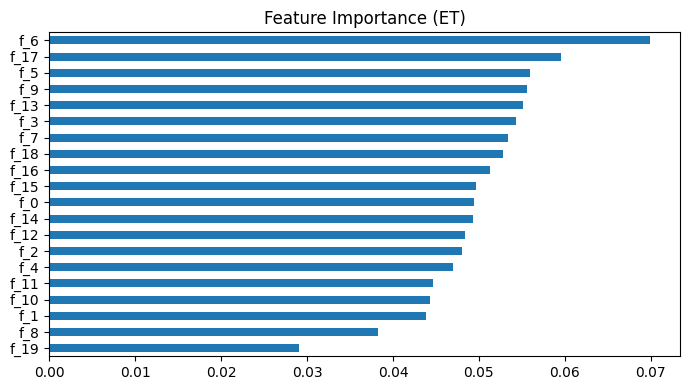

In [19]:

def plot_feature_importance(model, feature_names, title):
    import pandas as _pd, matplotlib.pyplot as _plt
    if hasattr(model, 'feature_importances_'):
        imp = _pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
        display(imp.head(10))
        _plt.figure(figsize=(7,4))
        imp.head(20).iloc[::-1].plot(kind='barh')
        _plt.title(title); _plt.tight_layout(); _plt.show()
    else:
        print("Model has no 'feature_importances_' attribute. Skipping.")

best_model = models[best_model_name]
best_model.fit(X, y)
plot_feature_importance(best_model, feature_cols, f"Feature Importance ({best_model_name})")

if not hasattr(best_model, 'feature_importances_'):
    proxy_rf = RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1)
    proxy_rf.fit(X, y)
    plot_feature_importance(proxy_rf, feature_cols, "Feature Importance (RF proxy)")


In [21]:

best_model = models[best_model_name]
best_model.fit(X, y)
test_pred = best_model.predict(X_test)

import numpy as _np, pandas as _pd
sub = _pd.DataFrame({
    'id'   : _np.arange(len(test)),
    'code' : test['code'].values,
    'date' : test['date'].values,
    'y_pred': test_pred
})
out_csv_path = 'sample_submission.csv'
sub.to_csv(out_csv_path, index=False)
cv_csv = 'cv_scores.csv'
cv_summary.to_csv(cv_csv, index=True)
print("Wrote submission to:", out_csv_path)
print("Saved CV score table to:", cv_csv)
display(sub.head())


Wrote submission to: sample_submission.csv
Saved CV score table to: cv_scores.csv


,id,code,date,y_pred
0,0,s_0,550,0.010847
1,1,s_1,550,-0.021242
2,2,s_10,550,0.013077
3,3,s_1000,550,0.002871
4,4,s_1002,550,0.010005
